# `bo4mob` — the BO4Mob San Jose freeway instances (stage 1: data + liveness)

**What.** BO4Mob (Ryu, Kwon, Choi, Deshwal, Kang & Osorio 2025, NeurIPS 2025
Datasets & Benchmarks, `[ryu2025bo4mob]`,
[docs/REFERENCES.md](../../docs/REFERENCES.md)) poses five San Jose freeway
networks as high-dimensional black-box OD-ESTIMATION problems: minimise the
NRMSE between mesoscopic-SUMO link counts and real Caltrans PeMS sensor data.
There is **no ground-truth OD** — truth is the real sensor panel. This
notebook ships **stage 1 only**: data availability (a checksummed,
download-on-demand registry of four small instances) and pipeline liveness (a
mesoscopic-SUMO smoke run) — **no task family, no certificate, no estimator**.

**Why it is in the benchmark, and the honesty contract that governs it.**
BO4Mob is **the lab's own benchmark**
(`github.com/UMN-Choi-Lab/BO4Mob`, MIT). Hosting a benchmark the lab authored
inside a benchmark the lab authors is a standing honesty hazard — see
[docs/design/adr-034-bo4mob-scenarios.md](../../docs/design/adr-034-bo4mob-scenarios.md)
for the full dual-benchmark contract, reproduced verbatim below.

**Scope.** The dual-benchmark honesty contract (in-artifact, not only in
docs), the checksummed fetch of the four small instances (never
`5fullRegion`, which refuses to fetch by design), and an optional sumo-gated
pipeline-liveness cell reproducing the 1ramp smoke test.

## How this notebook is graded

**A notebook never claims a number it does not compute in that cell.** This
data notebook makes **no** certified-gap claim (stage 1 ships no certificate
at all — see Stage 2 in the ADR). What IS recomputed live: the in-artifact
disclosure strings, and — if `eclipse-sumo` is installed — the pipeline's
NRMSE and seed-stability, exactly as the guarded smoke test does
([README](../../README.md), *Certified, not self-reported*).

In [1]:
# Setup. bo4mob's data layer is numpy/stdlib only — no package guard cell for
# the notebook as a whole. ONE cell below (the pipeline-liveness demo) is
# OPTIONALLY sumo-gated: it degrades gracefully, printing a clear notice
# instead of raising, if `eclipse-sumo` is not installed — everything else in
# this notebook (the fetch, the citation, the honesty contract) needs no
# extra at all.
#
# The inline backend is Agg-based: figures render headlessly into the
# notebook, so CI can execute tutorials without a display. NEVER
# matplotlib.use("Agg") in-kernel — it silently suppresses inline capture.
%matplotlib inline
from tabench.data.bo4mob import (
    BO4MOB_ORIGIN,
    BO4MOB_REGISTRY,
    BO4MOB_SMOKE,
    Bo4MobHpcOnlyError,
    bo4mob_citation,
    fetch_bo4mob,
)

print(f"registered instances : {sorted(BO4MOB_REGISTRY)}")
print(f"CI smoke instance    : {BO4MOB_SMOKE}")

registered instances : ['1ramp', '2corridor', '3junction', '4smallRegion', '5fullRegion']
CI smoke instance    : 1ramp


## The dual-benchmark honesty contract (in-artifact, not only in docs)

The only honest claim shape (adr-034): TABenchmark hosts BO4Mob's instances
as **scenarios/data only** — never as validation of TABench methods, never a
claim to reproduce BO4Mob's published numbers (SUMO 1.12 in the paper vs the
shipped 1.27.1 wheel here — a measured schema drift, below), and never an
"independent replication" of BO4Mob's own BO leaderboard. Every registry
entry's `notes` carries this disclosure; it is recomputed and printed here,
not quoted from the ADR.

In [2]:
print(BO4MOB_ORIGIN)
assert "scenarios/data only" in BO4MOB_ORIGIN
assert "does not reproduce BO4Mob's published numbers" in BO4MOB_ORIGIN
for spec in BO4MOB_REGISTRY.values():
    assert spec.notes == BO4MOB_ORIGIN or spec.notes.startswith(BO4MOB_ORIGIN)
print()
print(bo4mob_citation(BO4MOB_REGISTRY["1ramp"]))

BO4Mob (Ryu, Kwon, Choi, Deshwal, Kang & Osorio 2025, arXiv:2510.18824, NeurIPS 2025 Datasets & Benchmarks) is a UMN Choi Lab benchmark, MIT-licensed; ground truth is public Caltrans PeMS detector data. TABenchmark hosts its instances as scenarios/data only (adr-034) — never as validation of TABench methods — and does not reproduce BO4Mob's published numbers (engine drift SUMO 1.12 -> 1.27.1). Fetched from BO4Mob @ ef571e6819a6.

Ryu, Kwon, Choi, Deshwal, Kang & Osorio (2025). BO4Mob: Bayesian Optimization Benchmarks for High-Dimensional Urban Mobility Problem. arXiv:2510.18824 (NeurIPS 2025 Datasets & Benchmarks). Data + engine: github.com/UMN-Choi-Lab/BO4Mob (commit ef571e6819a6, MIT). Ground truth: Caltrans PeMS detector data (public). BO4Mob is a UMN Choi Lab benchmark; TABenchmark hosts its instances as scenarios/data only (adr-034), not as validation of TABench methods, and does not reproduce BO4Mob's published numbers. Instance: 1ramp (3 OD pairs).


## The checksummed fetch: four small instances ship, `5fullRegion` refuses

`1ramp`/`2corridor`/`3junction`/`4smallRegion` are single-evaluation bundles
(< 1.2 MB total), fetched from a commit-pinned BO4Mob raw URL and verified
against a pinned SHA-256 on every load — never vendored (P9). `5fullRegion`
(10,100 OD pairs, 74 MB, ~11 h/eval) is registered metadata-only and **refuses
to fetch** — a named refusal, not a silent omission.

In [3]:
paths = fetch_bo4mob(BO4MOB_REGISTRY[BO4MOB_SMOKE])
print(f"{BO4MOB_SMOKE} bundle fetched and checksum-verified: {sorted(paths)}")
assert set(paths) == {"net", "taz", "od", "additional", "routes_single", "single_od", "config", "sensor"}

spec_full = BO4MOB_REGISTRY["5fullRegion"]
assert spec_full.hpc_only
try:
    fetch_bo4mob(spec_full)
    raise AssertionError("expected 5fullRegion to refuse to fetch")
except Bo4MobHpcOnlyError as exc:
    print(f"5fullRegion refused: {exc}"[:120] + "…")

1ramp bundle fetched and checksum-verified: ['additional', 'config', 'net', 'od', 'routes_single', 'sensor', 'single_od', 'taz']
5fullRegion refused: bo4mob 5fullRegion is HPC-only (74 MB, ~11 h/eval) and is registered metadata-only; refusing to fet…


## Not a `load_scenario` scenario

A BO4Mob instance is a mesoscopic-SUMO net with no BPR network and no true
OD, so no `Scenario` (Network/Demand/ReferenceSolution) can be built — that
is not a gap, it is the honest statement that these are data + an engine, not
an equilibrium instance.

In [4]:
from tabench import load_scenario

for key in ("1ramp", "bo4mob-1ramp"):
    try:
        load_scenario(key)
        raise AssertionError(f"expected load_scenario({key!r}) to raise")
    except KeyError as exc:
        print(f"load_scenario({key!r}) refused: {exc}"[:100] + "…")

load_scenario('1ramp') refused: "Unknown scenario '1ramp'; available: braess, tworoute, elastic-twor…
load_scenario('bo4mob-1ramp') refused: "Unknown scenario 'bo4mob-1ramp'; available: braess, tworoute…


## Pipeline liveness (optional, sumo-gated): the 1ramp smoke run

BO4Mob's own pipeline — `od2trips` route-fixing, then a mesoscopic SUMO run —
via the wheel binaries, reproducing the guarded smoke test
(`tests/test_bo4mob.py`). The measured 1.12 -> 1.27.1 schema drift: the
mesoscopic `edgeData` output carries no `nVehContrib` attribute, so the count
convention here uses `arrived + left` (BO4Mob's own), which still exists. This
cell degrades gracefully — no `eclipse-sumo` extra, no raise — since
everything else in this notebook needs no extra at all.

In [5]:
try:
    import sumo
except ModuleNotFoundError as exc:
    if exc.name != "sumo":
        raise
    print("eclipse-sumo not installed: skipping the pipeline-liveness demo "
          "(pip install tabench[sumo] to run it).")
else:
    import json
    import os
    import subprocess
    import tempfile
    import time
    from pathlib import Path

    from tabench.data import bo4mob as bo

    def _sbin(name):
        return os.path.join(sumo.SUMO_HOME, "bin", name)

    def _run(cmd, env, work, deadline):
        remaining = deadline - time.monotonic()
        if remaining <= 0:
            raise RuntimeError("bo4mob smoke exceeded the wall budget")
        proc = subprocess.run(
            cmd, env=env, cwd=work, stdin=subprocess.DEVNULL,
            capture_output=True, text=True, timeout=remaining,
        )
        if proc.returncode != 0:
            raise RuntimeError(f"{cmd[0]} failed (rc={proc.returncode}): {proc.stderr[-800:]}")

    def _run_1ramp(paths, work, seed):
        cfg = json.loads(paths["config"].read_text())
        sim_end = float(cfg["sim_end_time"])
        od_end = int(cfg["od_end_time"])
        s0, s1 = float(cfg["sensor_start_time"]), float(cfg["sensor_end_time"])
        env = {**os.environ, "SUMO_HOME": sumo.SUMO_HOME}
        deadline = time.monotonic() + 120.0

        od_filled = work / f"od_filled_{seed}.xml"
        bo.fill_single_od(paths["od"], paths["single_od"], od_filled, od_end)
        trips_before = work / f"trips_before_{seed}.xml"
        _run([
            _sbin("od2trips"), "--spread.uniform", "--taz-files", str(paths["taz"]),
            "--tazrelation-files", str(od_filled), "-o", str(trips_before),
        ], env, work, deadline)
        trips_fixed = work / f"trips_fixed_{seed}.xml"
        n_trips = bo.fix_routes_single(trips_before, paths["routes_single"], trips_fixed)
        edge_data_name = f"edge_data_{seed}.xml"
        add_local = work / f"additional_local_{seed}.xml"
        bo.local_edgedata_additional(paths["additional"], add_local, edge_data_name)
        _run([
            _sbin("sumo"), "--mesosim", "true", "--net-file", str(paths["net"]),
            "--routes", str(trips_fixed), "-b", "0", "-e", str(int(sim_end)),
            "--additional-files", str(add_local), "--ignore-route-errors", "true",
            "--xml-validation", "never", "--no-warnings", "--seed", str(seed),
        ], env, work, deadline)
        edge_data = work / edge_data_name
        counts = bo.edgedata_counts(edge_data, s0, s1)
        return bo.bo4mob_nrmse(paths["sensor"], counts), len(counts), n_trips, bo.edgedata_has_nvehcontrib(edge_data)

    workdir = Path(tempfile.mkdtemp(prefix="tabench-bo4mob-"))
    results, drift = [], []
    for seed in (0, 1, 2):
        nrmse, n_edges, n_trips, saw = _run_1ramp(paths, workdir, seed)
        results.append(nrmse)
        drift.append(saw)
        print(f"seed={seed}  nrmse={nrmse:.6f}  edges={n_edges}  trips={n_trips}  nVehContrib={saw}")

    print(f"seed spread (max-min) : {max(results) - min(results):.2e}")
    assert max(results) - min(results) < 1e-3   # uncongested + speedDev=0 -> deterministic
    assert 1.5 < results[0] < 3.5                # loose, version-robust band
    assert not any(drift)                         # the measured 1.12 -> 1.27.1 schema drift

seed=0  nrmse=2.432471  edges=10  trips=3087  nVehContrib=False


seed=1  nrmse=2.432471  edges=10  trips=3087  nVehContrib=False


seed=2  nrmse=2.432471  edges=10  trips=3087  nVehContrib=False
seed spread (max-min) : 0.00e+00


## Visualize

Stage 1 has no BPR network, no certified link-flow artifact, and no OD-fit
diagram — nothing here is a road-link-flow object, so the viz rule (adr-035)
calls for plain matplotlib, not `tabench.viz`. There is nothing to plot yet:
the registry table below is the honest visual for a data-availability
notebook.

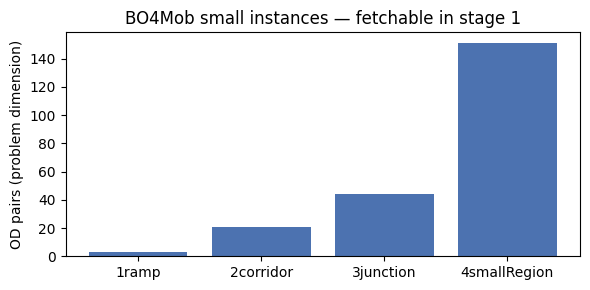

In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 3))
keys = [k for k in BO4MOB_REGISTRY if not BO4MOB_REGISTRY[k].hpc_only]
n_od = [BO4MOB_REGISTRY[k].n_od for k in keys]
ax.bar(keys, n_od, color="#4c72b0")
ax.set_ylabel("OD pairs (problem dimension)")
ax.set_title("BO4Mob small instances — fetchable in stage 1")
fig.tight_layout()
display(fig)
plt.close(fig)

## Takeaways & pointers

- **The dual-benchmark contract is in-artifact.** Every registry entry
  carries the affiliation, the license, and the "scenarios/data only" scope
  in its own `notes` — not just in this notebook or the ADR.
- **No certificate here, on purpose.** Stage 1 ships data + liveness only;
  the pinned-engine held-out-date observational certificate is a named
  stage-2 follow-up with its own ADR.
- **The engine numbers do not reproduce the paper's, and that is disclosed.**
  SUMO 1.12 (the paper) vs 1.27.1 (this wheel) is a measured schema drift,
  not a silent mismatch — `nVehContrib` is verifiably absent, checked above.
- **Where next.** `xu2024` ([01-xu2024.ipynb](01-xu2024.ipynb)) for the OTHER
  data family (real cities, a full `Scenario`, a genuine cross-implementation
  agreement check); the stage-2 certificate design in
  [docs/design/adr-034-bo4mob-scenarios.md](../../docs/design/adr-034-bo4mob-scenarios.md).